<a href="https://colab.research.google.com/github/DarkLyng/Challenge-TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [315]:
#Bibliotecas

import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [316]:
#Enlace

enlace = "https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json" #No funciona
enlace_raw = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

In [317]:
#Cargando los datos de Telecom X
r = requests.get(enlace_raw)
data = r.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [318]:
#Obteniendo información de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [319]:
#Normalizando el archivo TelecomX_Data.json
df_normalizado = pd.json_normalize(data)
df_normalizado.sample(10)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
2468,3445-HXXGF,Yes,Male,1,Yes,No,58,No,No phone service,DSL,...,Yes,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,45.30,2651.2
1918,2716-GFZOR,No,Male,0,Yes,No,43,Yes,No,Fiber optic,...,Yes,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),86.10,3551.65
5659,7729-XBTWX,No,Male,0,Yes,Yes,66,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,19.75,1344.5
1603,2273-QCKXA,No,Male,0,No,No,1,Yes,No,DSL,...,No,No,Yes,No,No,Month-to-month,No,Mailed check,49.05,49.05
1928,2725-IWWBA,No,Male,0,Yes,Yes,46,Yes,No,DSL,...,No,Yes,Yes,No,No,One year,No,Mailed check,56.90,2560.1
3812,5216-WASFJ,No,Female,1,Yes,No,31,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.85,2633.4
5153,7029-RPUAV,Yes,Male,1,Yes,No,17,Yes,Yes,Fiber optic,...,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.45,1622.45
6525,8969-PRHFK,No,Male,0,No,No,18,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.65,411.25
1409,2034-CGRHZ,Yes,Male,1,No,No,24,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.95,2496.7
4123,5651-CPDND,No,Male,0,No,No,10,Yes,No,DSL,...,No,No,No,No,No,Month-to-month,No,Mailed check,46.00,492.1


In [320]:
#Información de los datos normalizados
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [321]:
#Comprobación datos nulos
df_normalizado.isnull().sum().rename("Datos Nulos")

,Datos Nulos
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [322]:
#Comprobación de datos duplicados
df_normalizado.duplicated().sum()

np.int64(0)

In [323]:
#Comprobación de strings vacíos o con espacios en el DataFrame
for col in df_normalizado.select_dtypes(include='object').columns:
    espacios = df_normalizado[col].str.isspace().sum()
    vacios = (df_normalizado[col] == "").sum()
    if espacios > 0 or vacios > 0:
        print(f"Columna '{col}': {espacios} celdas con espacios y {vacios} celdas vacías.")

Columna 'Churn': 0 celdas con espacios y 224 celdas vacías.
Columna 'account.Charges.Total': 11 celdas con espacios y 0 celdas vacías.


In [324]:
#Se observa que tiene valores que son espacio vacíos
df_normalizado["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [325]:
#Se eliminan los espacios vacíos
df_normalizado = df_normalizado.query("Churn != '' ")


In [326]:
# Buscar valores no numéricos en account.Charges.Total
df_normalizado[~df_normalizado['account.Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')].head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,


In [327]:
#Eliminar estos espacios
df_normalizado=df_normalizado[df_normalizado['account.Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')]

In [328]:
#Reemplazar "No phone service" y "No internet service" en "No"
df_normalizado.replace("No phone service", "No", inplace=True)
df_normalizado.replace("No internet service", "No", inplace=True)
df_normalizado.replace("No", 0, inplace=True)
df_normalizado.replace("Yes", 1, inplace=True)

/tmp/ipykernel_147/664116977.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_normalizado.replace("Yes", 1, inplace=True)


In [329]:
# Convertir la columna account.Charges.Total a float
df_normalizado['account.Charges.Total'] = pd.to_numeric(df_normalizado['account.Charges.Total'], errors='coerce')

In [330]:
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   int64  
 5   customer.Dependents        7032 non-null   int64  
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   int64  
 8   phone.MultipleLines        7032 non-null   int64  
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   int64  
 11  internet.OnlineBackup      7032 non-null   int64  
 12  internet.DeviceProtection  7032 non-null   int64  
 13  internet.TechSupport       7032 non-null   int64  
 1

In [333]:
#Muestra de los datos ya corregidos
df_normalizado.sample(5)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
455,0643-OKLRP,1,Female,1,1,0,47,1,1,Fiber optic,...,0,0,0,0,0,Month-to-month,0,Electronic check,80.35,3825.85
7213,9921-QFQUL,0,Female,0,1,0,23,1,1,Fiber optic,...,0,1,0,0,1,Month-to-month,0,Mailed check,90.15,2044.95
1857,2640-PMGFL,1,Male,0,0,1,27,1,1,Fiber optic,...,0,0,1,0,0,Month-to-month,1,Electronic check,79.50,2180.55
1179,1685-BQULA,0,Female,0,0,0,40,1,1,Fiber optic,...,1,1,0,1,0,Month-to-month,1,Bank transfer (automatic),93.40,3756.40
6138,8400-WZICQ,0,Female,0,1,1,55,1,0,DSL,...,1,0,0,0,0,Month-to-month,0,Electronic check,55.70,3131.80


#📊 Carga y análisis

In [347]:
#Análisis descriptivo

df_describe = df_normalizado.describe().T

estilo = df_describe.style
estilo.format({"count": "{:.0f}",
                           "mean": "{:.2%}",
                           "std": "{:.2%}",
                           "25%": "{:.2%}",
                           "50%": "{:.2%}",
                           "75%": "{:.2%}",
                           "max": "{:.2f}",
                           "min": "{:.2f}"
                        })

,count,mean,std,min,25%,50%,75%,max
Churn,7032,26.58%,44.18%,0.00,0.00%,0.00%,100.00%,1.00
customer.SeniorCitizen,7032,16.24%,36.88%,0.00,0.00%,0.00%,0.00%,1.00
customer.Partner,7032,48.25%,49.97%,0.00,0.00%,0.00%,100.00%,1.00
customer.Dependents,7032,29.85%,45.76%,0.00,0.00%,0.00%,100.00%,1.00
customer.tenure,7032,3242.18%,2454.53%,1.00,900.00%,2900.00%,5500.00%,72.00
phone.PhoneService,7032,90.33%,29.56%,0.00,100.00%,100.00%,100.00%,1.00
phone.MultipleLines,7032,42.19%,49.39%,0.00,0.00%,0.00%,100.00%,1.00
internet.OnlineSecurity,7032,28.65%,45.22%,0.00,0.00%,0.00%,100.00%,1.00
internet.OnlineBackup,7032,34.49%,47.54%,0.00,0.00%,0.00%,100.00%,1.00
internet.DeviceProtection,7032,34.39%,47.50%,0.00,0.00%,0.00%,100.00%,1.00


In [348]:
#Distribución de evasión
df_evasion=df_normalizado['Churn'].value_counts(normalize=True).rename(index={1:"Si",0:"No"})*100
df_evasion

,proportion
Churn,
No,73.421502
Si,26.578498


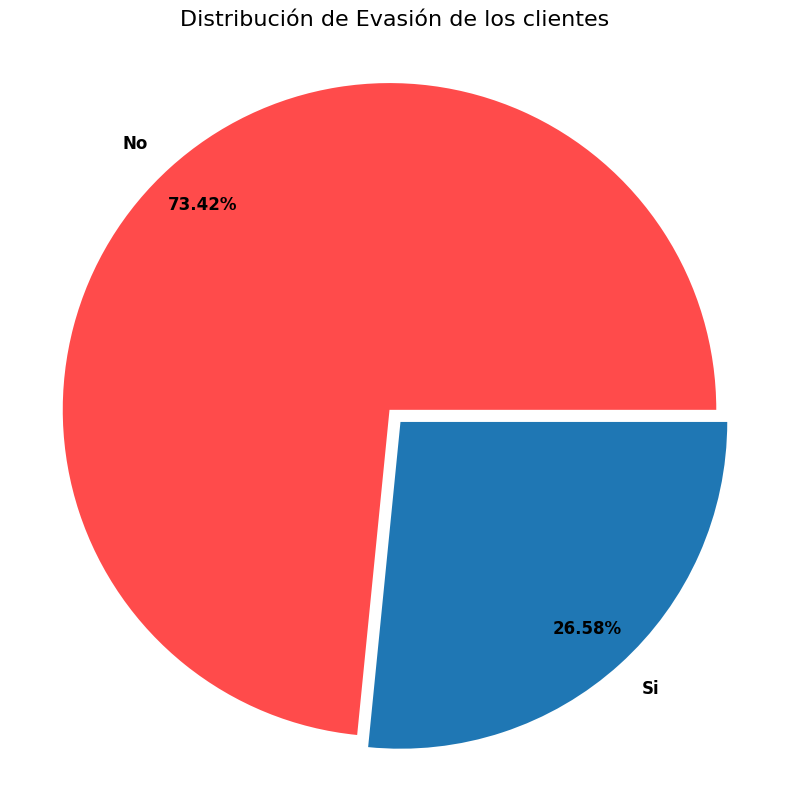

In [357]:
# 1. Preparar los datos
#conteo_cashback = df['cashback'].value_counts()

# 2. Configurar colores y estilo
colores = ['#FF4B4B', '#1F77B4'] # Rojo vibrante y Azul estándar
explode = (0.05, 0) # Pequeña separación para destacar la primera categoría

plt.figure(figsize=(8, 8))

# 3. Crear el gráfico de pastel base (con wedgeprops para el grosor de la rosquilla)
plt.pie(
    df_evasion,
    labels=df_evasion.index,
    autopct='%1.2f%%',
    startangle=0,
    colors=colores,
    explode=explode,
    pctdistance=0.85, # Aleja el texto del centro para que no quede sobre el hueco
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# 4. Dibujar el círculo central para convertirlo en rosquilla
#centro_circulo = plt.Circle((0, 0), 0.70, fc='white')
#fig = plt.gcf()
#fig.gca().add_artist(centro_circulo)

# 5. Personalización y título
plt.title('Distribución de Evasión de los clientes', fontsize=16, pad=20,)
plt.axis('equal') # Para que sea un círculo perfecto

plt.tight_layout()
plt.show()

In [ ]:
# Seleccionamos las 4 variables con mayor impacto en el negocio
columnas_top = [
    'Tipo_Contrato',   # Fundamental
    'Tipo_Internet',   # Tecnológica
    'Metodo_Pago',     # Financiera
    'Soporte_Tecnico'  # Servicio Agregado
]

fig, axes = plt.subplots(2,2, figsize=(20,10))
axes = axes.flatten() # Con esto dejamos de pensar en coordenadas (x,y) y lo pasamos a un formato lista

for col, ax in zip(columnas_top, axes):
  sns.countplot(data=df, hue="Abandono", x=col, ax=ax, palette="Paired")
  ax.set_title(f'Distribución de evasión por {col}')
  ax.set_ylabel('Cantidad')
  ax.legend(title= '¿Abandono?', labels= ["No", "Si"])

plt.tight_layout()
plt.show()

In [ ]:
#Conteo de evasión por variables numéricas



#📄Informe final